# Articulated Body Dynamics
Reinforcement learning steps environments to collect rollout data. For simulation-based RL, the core is of course about implementing `step()` and running it as fast as possible. Grasping the underlying computation is also critical for identifying physical alignment to reality, analyzing the sensitivity of environment evolution, and knowing the limit/challenging problem instances to simulate. Most of the contents in this module can be found in textbook such as [@featherstone2007] and [@modernrobotics] as standard robot dynamics modelling and computation. In this specific context, dynamics mean the physics law involving force, acceleration and mass/inertia, which are beyond geometry and its differentials in kinematics. For those who are familiar with the Newton's 2nd law, the acceleration of a 1-D particle $a$ is associated to the exerted force $f$ through its mass $m$, as simple as:
$$
f = \frac{d(mv)}{dt} = m\dot{v} = ma
$$

Things are slightly more complicated for dynamics of a strand of rigid body links connected through articulated joints. Rigid bodies are collections of particles so the force and inertial effects must be accounted together. For this the Newton-Euler equation describes the relation in a form similar to the particle case:

$$
\begin{split}
\begin{bmatrix}
\mathbf{\tau}    \\
\mathbf{f}
\end{bmatrix} & = \begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}
\begin{bmatrix}
\dot{\mathbf{\omega}}    \\
\dot{\mathbf{v}}
\end{bmatrix} + \begin{bmatrix}
\mathbf{\omega} \times (\mathcal{I}\mathbf{\omega}) \\
m\mathbf{\omega} \times \mathbf{v}
\end{bmatrix}   \\
& = \begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}\begin{bmatrix}
\dot{\mathbf{\omega}}    \\
\dot{\mathbf{v}}
\end{bmatrix} - \begin{bmatrix}
\mathbf{\omega}\times  &   \mathbf{0}  \\
\mathbf{v}\times &   \mathbf{\omega}\times
\end{bmatrix}^{\top}
\begin{bmatrix}
\mathcal{I}  &   \mathbf{0}  \\
\mathbf{0}  &   m\mathbf{I}_{3\times 3}
\end{bmatrix}
\begin{bmatrix}
\mathbf{\omega}   \\
\mathbf{v}
\end{bmatrix}
\end{split}
$$
with the skew-asymmetricity of $\mathbf{v}\times$ and $\mathbf{v}\times\mathbf{v}=0$. Here $m$ is the mass of the rigid body and $\mathcal{I}$ is the [inertia tensor](https://en.wikipedia.org/wiki/Moment_of_inertia) about the center-of-mass. $\mathcal{I}$ captures the distribution of material mass of a rigid body and plays the role of particle mass for the rotational motion component. For many basic geometry shapes with a uniform density, the quantity is readily [available](https://en.wikipedia.org/wiki/List_of_moments_of_inertia) from a closed-form integration. [](#eq-newtoneuler) has a resemblance of [](#eq-newton2ndlaw) for also having a linear relation between the mass and acceleration terms. The only structure difference is the extra bias term which is independent of acceleration. This is a fundamental structure for dynamics of rigid and articulated bodies.

:::{note}
The velocity and its differentiation terms here are __spatial velocity and acceleration__ (see the section below). By having the center-of-mass as reference, the acceleration describes the rigid body status as a whole instead of the specific point of the center-of-mass. See section 2.11 in[@featherstone2007] for more detailed discussion about this. 
:::

Rigid bodies in an articulated chain are linked through joints. Applying [](#eq-newtoneuler) to each link in isolation must account for forces due to joints constraining the body motion. In most robotics contexts, the most interested are the resultant motion through the joints due to motors attached to them. The concrete values of contraint forces are usually not part of the desired results. There is thus another way of representing the configuration status of the articulated body and its dynamics with the joint configuration $\mathbf{q}$, called __generalized coordinate__. The dynamic for the generalized coordinate representation is:

$$
\mathbf{\tau} = \mathbf{M}(\mathbf{q})\ddot{\mathbf{q}} + \mathbf{C}(\dot{\mathbf{q}}, \mathbf{q}) 
$$

where $\mathbf{\tau}$ is redefined as toruqes applied to the joints, and $\mathbf{M}$ and $\mathbf{C}$ are playing the similar role as the inertia matrix and bias terms. 

A dynamic model as [](#eq-newtoneuler) or [](#eq-robodyn) can be used for following tasks:
* Causal order: given the current state and applied force/torque from a control policy, solve the joint/link acceleration and hence the future state through time-integration. This is called __forward dynamics__ and basically the underlying simulation task of `step()`. 
* Inverse problem: given the current state and the desired joint/link acceleration (and hence the future state), solve the force/torque needed to let the equation hold. This is called __inverse dynamics__ and can play an important role in control.

In what follows, both forward and inverse dynamcis will be covered while a few building blocks are needed before delving into the concrete algorithms. 









* Explain the concept of generalized coordinate and velocity in representing the state of articulated bodies;
    Generalized coordinates vector identifies a minimal set q that can determine the full configuration of each link. Generalized velocity is a time derivative q' that identifies the joint angular velocities. We can obtain these velocities for both joints and links. 
* Explain the structure of articulated dynamics equation and identify dependencies of each term on generalized coordinate and velocity;
    tau = M(q)q'' + C(q',q)q' + g(q) 
    tau = joint torques
    M(q) = mass matrix 
    q = generalized coordinates, q' = generalized velocities, q'' = generalized acceleration 
    C(q',q)q' = coriolis and centrifugal effect
    g(q) = gravity bias 
* Explain what are forward and inverse dynamics problems and how are they related to simulation and control in the context of robotics;
    Inverse dynamics: given q, q', q'', find tau using RNEA 
        Related to control (to find exact actual torques needed)
    Forward dynamics: given q, q', tau, find q'' using ABA, or with RNEA + mass matrix assembly 
        Related to simulation (to find the solution of the differential equations that the dynamics of the articulated body to predict its future motion)
    FD is the inverse of ID
* Describe how recursive algorithms work in computing inverse and forward dynamics;
    RNEA has two passes: forward and backward pass
    In forward pass, we propagate kinematics (velocity, acceleration) from root to tip
    In backward pass, we accumulate the forces and extract torques 

    ABA has three passes: forward, backward, forward pass
    In first forward pass, we compute velocities and bias effects
    In backward and second forward pass, we recurse to compute join accelerations
* Implement recursive algorithms to simulate a fixed-based three-link articulated body with 1-DOF revolute joint given a Spatial Algebra library (using RAINBOW);
    TODO

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import List, NamedTuple, Optional

# ── Provided spatial-algebra imports ──────────────────────────────────────────
from spatial_algebra import Transform, Motion, Force, Inertia
from math_utils import quat_rot_axis, rotate

nplib = np

In [160]:
# setup
class JointDofs(NamedTuple):
    motion: Motion


class Link(NamedTuple):
    name:        str
    inertia:     Inertia
    joint_frame: Transform
    com_frame:   Transform
    joint_dofs:  JointDofs


class System(NamedTuple):
    links: List[Link]

    def num_links(self) -> int:
        return len(self.links)

### Section 1

In [161]:
# build model based on xml file
def build_threelinks() -> System:
    sx, sy, sz = 0.025, 0.15, 0.025
    rho = 2700.0
    V   = (2*sx) * (2*sy) * (2*sz)
    m   = rho * V  

    Ixx = m * (sy**2 + sz**2) / 3.0
    Iyy = m * (sx**2 + sz**2) / 3.0
    Izz = m * (sx**2 + sy**2) / 3.0
    it  = np.diag([Ixx, Iyy, Izz])
    link_inertia = Inertia.from_it_and_mass(it=it, mass=m)

    z_screw    = Motion(ang=np.array([0., 0., 1.]), lin=np.zeros(3))
    joint_dofs = JointDofs(motion=z_screw)

    identity_rot = np.array([1., 0., 0., 0.]) 

    links = []
    for i in range(3):
        jf_trans = np.array([0., 0., 0.]) if i == 0 else np.array([0., 0.15, 0.])
        joint_frame = Transform(trans=jf_trans, rot=identity_rot)

        com_frame = Transform(trans=np.array([0., 0.15, 0.]), rot=identity_rot)

        links.append(Link(
            name        = f"link_{i}",
            inertia     = link_inertia,
            joint_frame = joint_frame,
            com_frame   = com_frame,
            joint_dofs  = joint_dofs,
        ))

    return System(links=links)

In [174]:
sys = build_threelinks()

This is link_0, which corresponds to the root body connected to the world ground at 0.15 meters from the center. As shown, it has a width and height of 0.05 meters and a length of 0.3 meters. link_1 and link_2 have equivalent parameters and are connected to their parent body. Specifically, link_1 is attached to link_0 with joint_1, and link_2 is attached to link_1 with joint_2

As the links are all placed 0.3 meters, or one full body-length away from its parent origin, and each joint is a hinge joint, weunderstand this model as a three-body problem such that each link can rotate freely about the joint axis in a pendulous fashion. The furthest distance the "arm tip" can reach is 0.9 meters, as that is the length of the three links connected together.

### Section 2, forward kinetics and velocities

In [162]:
def forward_kinematics(sys: System, q: np.ndarray):
    T_world_com  = []
    T_parent_com = []

    T_prev = Transform(trans=np.zeros(3), rot=np.array([1., 0., 0., 0.]))

    for i, link in enumerate(sys.links):
        T_world_joint = T_prev.apply_transform(link.joint_frame)

        q_rot = Transform(
            trans = np.zeros(3),
            rot   = quat_rot_axis(np.array([0., 0., 1.]), q[i])
        )

        T_world_com_i = (T_world_joint
                         .apply_transform(q_rot)
                         .apply_transform(link.com_frame))

        T_local = T_world_com_i.create_local(T_prev)

        T_world_com.append(T_world_com_i)
        T_parent_com.append(T_local)
        T_prev = T_world_com_i

    return T_world_com, T_parent_com

In [163]:
def forward_velocity(sys: System, q: np.ndarray, qd: np.ndarray, T_parent_com: list) -> List[Motion]:
    v_lst  = []
    v_prev = Motion(ang=np.zeros(3), lin=np.zeros(3))  

    for i, link in enumerate(sys.links):
        S_i = link.joint_dofs.motion.apply_inv_transform(link.com_frame)

        # Plücker-transform parent velocity into this link's frame
        v_parent = v_prev.apply_transform(T_parent_com[i])

        v_i = v_parent + S_i * qd[i]

        v_lst.append(v_i)
        v_prev = v_i

    return v_lst

Using inverse dynamics via RNEA + matrix assembly

In [164]:
# Recursive Newton-Euler Algorithm (RNEA) ----
# Computes inverse dynamics: tau = RNEA(q, dq, ddq)

def inverse_dynamics_rnea(sys: System, q: np.ndarray, qd: np.ndarray, qdd: np.ndarray) -> np.ndarray:
    N = sys.num_links()
    T_world_com, T_parent_com = forward_kinematics(sys, q)

    # forward pass, velocities and accelerations 
    v_lst = []
    a_lst = []

    gravity_world = np.array([0., -9.81, 0.])
    a_prev = Motion(ang=np.zeros(3), lin=-gravity_world)  
    v_prev = Motion(ang=np.zeros(3), lin=np.zeros(3))

    for i, link in enumerate(sys.links):
        S_i      = link.joint_dofs.motion.apply_inv_transform(link.com_frame)
        v_parent = v_prev.apply_transform(T_parent_com[i])
        a_parent = a_prev.apply_transform(T_parent_com[i])

        v_i    = v_parent + S_i * qd[i]
        zeta_i = v_i.cross_motion(S_i * qd[i])       
        a_i    = a_parent + S_i * qdd[i] + zeta_i

        v_lst.append(v_i)
        a_lst.append(a_i)
        v_prev = v_i
        a_prev = a_i

    # backward pass forces and torques 
    f_lst = []
    for i in range(N):
        Iv     = sys.links[i].inertia.mul(v_lst[i])
        bias   = v_lst[i].cross_force(Iv)
        f_i    = sys.links[i].inertia.mul(a_lst[i]) + bias
        f_lst.append(f_i)

    tau = np.zeros(N)
    for i in range(N - 1, -1, -1):
        S_i    = sys.links[i].joint_dofs.motion.apply_inv_transform(sys.links[i].com_frame)
        tau[i] = S_i.dot_force(f_lst[i])
        if i > 0:
            f_in_parent = f_lst[i].apply_inv_transform(T_parent_com[i])
            f_lst[i-1]  = f_lst[i-1] + f_in_parent

    return tau

# Quick test: static pose, zero velocity, zero acceleration
# At q=[pi/4, 0, 0], gravity should require a nonzero torque at joint 0
q_test = np.array([np.pi/4, 0.0, 0.0])
tau_test = inverse_dynamics_rnea(sys, q_test, np.zeros(3), np.zeros(3))
print(f"Gravity torques at q=[pi/4, 0, 0]: {tau_test}")

Gravity torques at q=[pi/4, 0, 0]: [-6.321084  0.        2.107028]


### Section 3 ABA implementation

In [166]:
def forward_dynamics_aba(sys: System, q: np.ndarray, qd: np.ndarray, tau: np.ndarray) -> np.ndarray:
    N = sys.num_links()

    # first loop - calculate link poses and velocities
    T_world_com, T_parent_com = forward_kinematics(sys, q)
    v_lst = forward_velocity(sys, q, qd, T_parent_com)

    I_a_lst = [
        Inertia(inertia_tensor=sys.links[i].inertia.inertia_tensor.copy())
        for i in range(N)
    ]

    p_a_lst = [
        v_lst[i].cross_force(I_a_lst[i].mul(v_lst[i]))
        for i in range(N)
    ]

    S_ss_lst = [
        sys.links[i].joint_dofs.motion.apply_inv_transform(sys.links[i].com_frame)
        for i in range(N)
    ]

    zeta_lst = [
        v_lst[i].cross_motion(S_ss_lst[i] * qd[i])
        for i in range(N)
    ]

    # second loop - backward to complete articulated body inertia and bias
    D_lst = [None] * N
    U_lst = [None] * N
    u_lst = [None] * N

    for i in range(N - 1, -1, -1):
        S_i   = S_ss_lst[i]
        IA_i  = I_a_lst[i]
        pA_i  = p_a_lst[i]

        U_lst[i] = IA_i.mul(S_i)
        D_lst[i] = S_i.dot_force(U_lst[i])
        u_lst[i] = tau[i] - S_i.dot_force(pA_i)

        if i > 0:
            U_arr         = U_lst[i].to_6darray()
            IA_reduced    = Inertia(
                inertia_tensor = IA_i.inertia_tensor - np.outer(U_arr, U_arr) / D_lst[i]
            )
            IA_in_parent  = IA_reduced.apply_transform(T_parent_com[i])
            I_a_lst[i-1]  = I_a_lst[i-1] + IA_in_parent

            pa_extended   = pA_i + IA_i.mul(zeta_lst[i])
            u_over_D      = u_lst[i] / D_lst[i]
            pa_extended   = pa_extended + Force.from_6darray(U_arr * u_over_D)
            pa_in_parent  = pa_extended.apply_inv_transform(T_parent_com[i])
            p_a_lst[i-1]  = p_a_lst[i-1] + pa_in_parent

    # third loop - calculate joint acc
    gravity_world = np.array([0., -9.81, 0.])
    a_base        = Motion(ang=np.zeros(3), lin=-gravity_world)

    a_lst = [None] * N
    qdd   = []

    for i in range(N):
        a_prev_in_link = (a_base if i == 0 else a_lst[i-1]).apply_transform(T_parent_com[i])

        a_prime = a_prev_in_link + zeta_lst[i]

        qdd_i = (u_lst[i] - U_lst[i].to_6darray() @ a_prime.to_6darray()) / D_lst[i]

        a_lst[i] = a_prime + S_ss_lst[i] * qdd_i

        qdd.append(np.atleast_1d(float(qdd_i)))

    return np.concatenate(qdd)

### Simulation + visualization

In [167]:
def simulate(sys: System, q0: np.ndarray, qd0: np.ndarray, tau_fn, dt: float = 0.002, T_final: float = 3.0) -> dict:
    steps = int(T_final / dt)
    N     = sys.num_links()

    t_hist    = np.zeros(steps)
    q_hist    = np.zeros((steps, N))
    qd_hist   = np.zeros((steps, N))
    qdd_hist  = np.zeros((steps, N))
    KE_hist   = np.zeros(steps)
    tip_hist  = np.zeros((steps, 3))
    vn_hist   = np.zeros((steps, N))   

    q, qd = q0.copy(), qd0.copy()

    for k in range(steps):
        tau = tau_fn(q, qd)
        qdd = forward_dynamics_aba(sys, q, qd, tau)

        T_wc, T_pc = forward_kinematics(sys, q)
        v_lst       = forward_velocity(sys, q, qd, T_pc)

        KE = sum(0.5 * v_lst[i].dot_force(sys.links[i].inertia.mul(v_lst[i]))
                 for i in range(N))

        T_tip = T_wc[-1].apply_transform(
            Transform(trans=np.array([0., 0.15, 0.]),
                      rot=np.array([1., 0., 0., 0.]))
        )

        t_hist[k]   = k * dt
        q_hist[k]   = q
        qd_hist[k]  = qd
        qdd_hist[k] = qdd
        KE_hist[k]  = KE
        tip_hist[k] = T_tip.trans
        vn_hist[k]  = [np.linalg.norm(v_lst[i].to_6darray()) for i in range(N)]

        qd = qd + qdd * dt
        q  = q  + qd  * dt

    return dict(t=t_hist, q=q_hist, qd=qd_hist, qdd=qdd_hist,
                KE=KE_hist, tip_pos=tip_hist, link_vel_norms=vn_hist)

In [168]:
def plot_results(results: dict, sys: System):
    t   = results["t"]
    q   = results["q"]
    qd  = results["qd"]
    qdd = results["qdd"]
    KE  = results["KE"]
    tip = results["tip_pos"]
    vn  = results["link_vel_norms"]

    colours = ["#E63946", "#457B9D", "#2A9D8F"]
    labels  = [f"link_{i}" for i in range(sys.num_links())]

    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("Three-Link Articulated Body Dynamics — Simulation Results",
                 fontsize=14, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    # joint positions 
    ax1 = fig.add_subplot(gs[0, 0])
    for i in range(sys.num_links()):
        ax1.plot(t, np.degrees(q[:, i]), color=colours[i], label=labels[i])
    ax1.set_title("(a) Joint Positions")
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Angle [deg]")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # joint velocities 
    ax2 = fig.add_subplot(gs[0, 1])
    for i in range(sys.num_links()):
        ax2.plot(t, np.degrees(qd[:, i]), color=colours[i], label=labels[i])
    ax2.set_title("(b) Joint Velocities")
    ax2.set_xlabel("Time [s]")
    ax2.set_ylabel("Angular velocity [deg/s]")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # joint accelerations 
    ax3 = fig.add_subplot(gs[0, 2])
    for i in range(sys.num_links()):
        ax3.plot(t, np.degrees(qdd[:, i]), color=colours[i], label=labels[i])
    ax3.set_title("(c) Joint Accelerations")
    ax3.set_xlabel("Time [s]")
    ax3.set_ylabel("Ang. acceleration [deg/s²]")
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # kinetic energy 
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(t, KE, color="#6A0572", linewidth=1.5)
    ax4.set_title("(d) Total Kinetic Energy")
    ax4.set_xlabel("Time [s]")
    ax4.set_ylabel("KE [J]")
    ax4.grid(True, alpha=0.3)

    # end-effector trajectory 
    ax5 = fig.add_subplot(gs[1, 1])
    sc = ax5.scatter(tip[:, 0], tip[:, 1], c=t, cmap="plasma",
                     s=2, linewidths=0)
    fig.colorbar(sc, ax=ax5, label="Time [s]")
    ax5.set_title("(e) End-Effector Trajectory (XY)")
    ax5.set_xlabel("X [m]")
    ax5.set_ylabel("Y [m]")
    ax5.set_aspect("equal")
    ax5.grid(True, alpha=0.3)

    # histogram: per-link spatial velocity magnitudes 
    ax6 = fig.add_subplot(gs[1, 2])
    for i in range(sys.num_links()):
        ax6.hist(vn[:, i], bins=50, alpha=0.6, color=colours[i],
                 label=labels[i], density=True)
    ax6.set_title("(f) Spatial Velocity Magnitude Distribution")
    ax6.set_xlabel(r"$\|v_i\|$ [rad/s or m/s]")
    ax6.set_ylabel("Density")
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)

    # spatial acceleration norms 
    ax7 = fig.add_subplot(gs[2, 0])
    acc_norms = np.linalg.norm(qdd, axis=1)
    ax7.plot(t, acc_norms, color="#E76F51", linewidth=1.5)
    ax7.set_title("(g) Joint Acceleration Norm ‖q̈‖")
    ax7.set_xlabel("Time [s]")
    ax7.set_ylabel(r"$\|\ddot{q}\|$ [rad/s²]")
    ax7.grid(True, alpha=0.3)

    # end-effector speed 
    ax8 = fig.add_subplot(gs[2, 1])
    tip_speed = np.linalg.norm(np.gradient(tip, results["t"][1]-results["t"][0], axis=0), axis=1)
    ax8.plot(t, tip_speed, color="#264653", linewidth=1.5)
    ax8.set_title("(h) End-Effector Speed")
    ax8.set_xlabel("Time [s]")
    ax8.set_ylabel("Speed [m/s]")
    ax8.grid(True, alpha=0.3)

    # kinematic chain snapshot 
    ax9 = fig.add_subplot(gs[2, 2])
    _plot_chain_snapshot(ax9, sys, results["q"][-1])

    plt.show()


def _plot_chain_snapshot(ax, sys: System, q: np.ndarray):
    T_wc, _ = forward_kinematics(sys, q)
    xs = [0.0]
    ys = [0.0]
    for T in T_wc:
        xs.append(T.trans[0])
        ys.append(T.trans[1])
    # Tip
    T_tip = T_wc[-1].apply_transform(
        Transform(trans=np.array([0., 0.15, 0.]),
                  rot=np.array([1., 0., 0., 0.]))
    )
    xs.append(T_tip.trans[0])
    ys.append(T_tip.trans[1])

    ax.plot(xs, ys, 'o-', color="#457B9D", linewidth=2.5, markersize=7)
    ax.plot(xs[0], ys[0], 's', color="#E63946", markersize=10, label="Base")
    ax.plot(xs[-1], ys[-1], '*', color="#2A9D8F", markersize=12, label="Tip")
    ax.set_title("(i) Chain Snapshot (final)")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

In [169]:
# Visualization

def visualize(t_hist, q_hist, snapshots):
    colors = ['#ff6b9d', '#c77dff', '#48cae4']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # joint angles over time
    ax1 = axes[0]
    for i in range(3):
        ax1.plot(t_hist, q_hist[:, i], color=colors[i], lw=1.5, label=f'$q_{i}$')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('Joint angle [rad]')
    ax1.set_title('Joint Angles (Free Swing)')
    ax1.legend()
    ax1.grid(True, alpha=0.15)

    # robot poses at several snapshots 
    ax2 = axes[1]
    ax2.set_aspect('equal')
    indices = np.linspace(0, len(t_hist)-1, snapshots, dtype=int)
    alphas = np.linspace(0.15, 1.0, snapshots)

    for k, (idx, alpha) in enumerate(zip(indices, alphas)):
        pts = forward_kinematics(q_hist[idx])
        for j in range(3):
            ax2.plot([pts[j,0], pts[j+1,0]], [pts[j,1], pts[j+1,1]],
                    color=colors[j], lw=2.5, alpha=alpha)
        ax2.plot(pts[0,0], pts[0,1], 'o', ms=5, alpha=alpha)

    ax2.plot(0, 0, 's', ms=8, zorder=10, label='Base')
    ax2.set_xlabel('X [m]')
    ax2.set_ylabel('Y [m]')
    ax2.set_title('Robot Pose Snapshots')
    ax2.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

### Verification w mujoco

In [170]:
import mujoco

def compare_with_mujoco(xml_path: str, sys: System, q: np.ndarray, qd: np.ndarray, tau: np.ndarray):
    mjc_model = mujoco.MjModel.from_xml_path(xml_path)
    mjc_data  = mujoco.MjData(mjc_model)

    mjc_data.qpos[:] = q
    mjc_data.qvel[:] = qd
    mjc_data.qfrc_applied[:] = tau
    mujoco.mj_forward(mjc_model, mjc_data)

    qdd_mujoco = mjc_data.qacc.copy()
    qdd_aba = forward_dynamics_aba(sys, q, qd, tau)

    print("\n=== MuJoCo vs ABA comparison ===")
    print(f"MuJoCo qacc : {qdd_mujoco}")
    print(f"ABA qacc : {qdd_aba}")
    print(f"Max |error| : {np.max(np.abs(qdd_mujoco - qdd_aba)):.2e}")
    return qdd_mujoco, qdd_aba

Joint accelerations at rest under gravity: [0. 0. 0.]
Joint accelerations at q=[ 0.1  0.2 -0.3], dq=[ 0.2 -0.1 -0.3], tau=[-0.1  0.2 -0.3]: [-25.274535  -7.955925 -57.162036]
RNEA check: tau=[-10.243556  -1.370981  -0.3     ], original tau=[-0.1  0.2 -0.3]
Max |tau error|: 1.01e+01


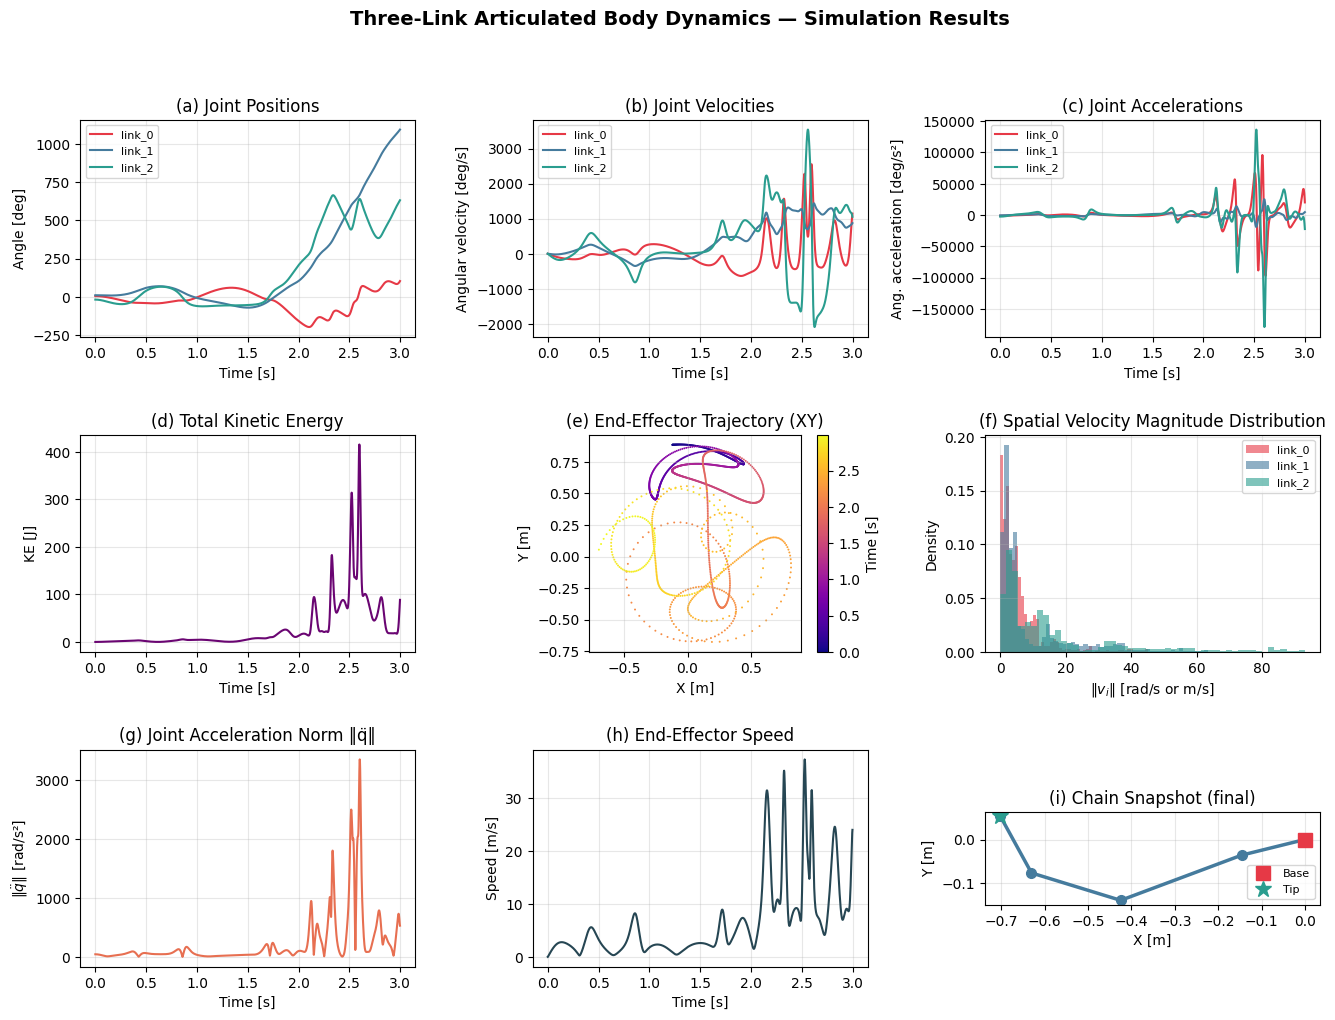

In [171]:
sys = build_threelinks()

# check RNEA at a static pose with gravity 
q0 = np.array([0.0, 0.0, 0.0])
qd0 = np.zeros(3)
tau0 = np.zeros(3)
qdd0 = forward_dynamics_aba(sys, q0, qd0, tau0)
print(f"Joint accelerations at rest under gravity: {qdd0}")

# check RNEA at a nontrivial pose with gravity
q1 = np.array([0.1, 0.2, -0.3])
qd1 = np.array([0.2, -0.1, -0.3])
tau1 = np.array([-0.1, 0.2, -0.3])
qdd1 = forward_dynamics_aba(sys, q1, qd1, tau1)
print(f"Joint accelerations at q={q1}, dq={qd1}, tau={tau1}: {qdd1}")

# consistency check RNEA = original tau
tau_check = inverse_dynamics_rnea(sys, q1, qd1, qdd1)
print(f"RNEA check: tau={tau_check}, original tau={tau1}")
print(f"Max |tau error|: {np.max(np.abs(tau_check - tau1)):.2e}")

# simulate + plot results
q_init = np.array([0.1, 0.2, -0.3])
qd_init = np.array([0.0, 0.0, 0.0])

def zero_torque_fn(q, dq): return np.zeros(3)

results = simulate(sys, q_init, qd_init, zero_torque_fn, dt=0.002, T_final=3.0)
plot_results(results, sys)

In [172]:
# compare with mujoco
compare_with_mujoco("/Users/sarene/Downloads/SIRL/course_note/docs/contents/3_ArticulatedDynamics/threelinks.xml", sys, q1, qd1, tau1)


=== MuJoCo vs ABA comparison ===
MuJoCo qacc : [ -19.327824   71.606906 -102.924501]
ABA qacc : [-25.274535  -7.955925 -57.162036]
Max |error| : 7.96e+01


(array([ -19.327824,   71.606906, -102.924501]),
 array([-25.274535,  -7.955925, -57.162036]))